<a href="https://colab.research.google.com/github/dohun0310/BigData_computing_2026/blob/main/%E1%84%8C%E1%85%AE%E1%86%BC%E1%84%80%E1%85%A1%E1%86%AB%E1%84%80%E1%85%A9%E1%84%89%E1%85%A1_%E1%84%91%E1%85%B3%E1%84%85%E1%85%A9%E1%84%80%E1%85%B3%E1%84%85%E1%85%A2%E1%84%86%E1%85%B5%E1%86%BC_%E1%84%80%E1%85%AA%E1%84%8C%E1%85%A6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  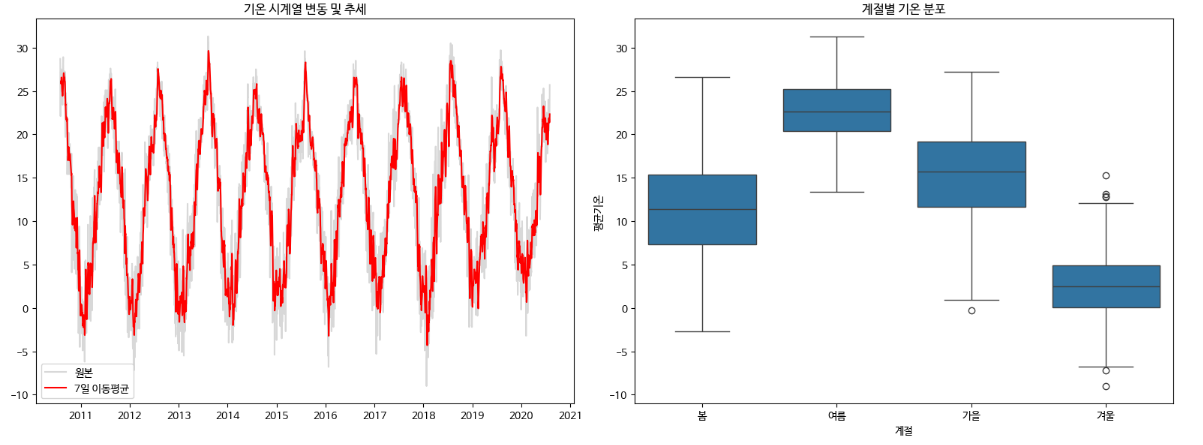

  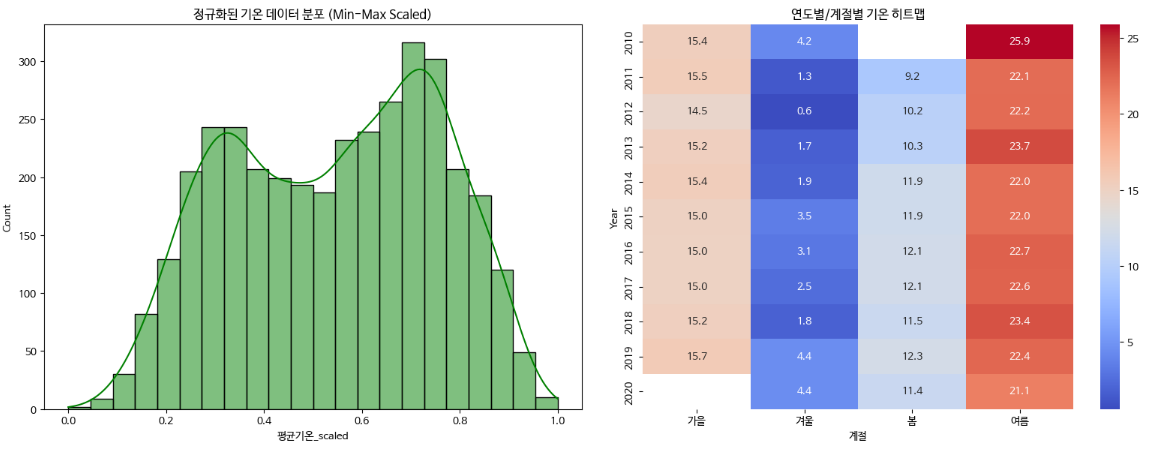



✅ 환경 설정 및 한글 폰트 로드 완료


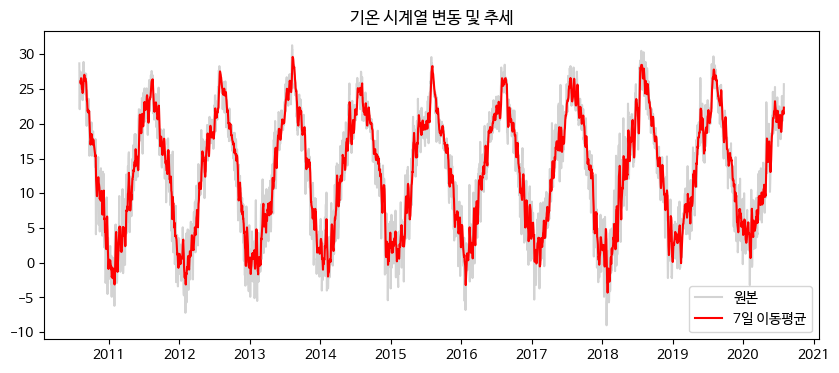

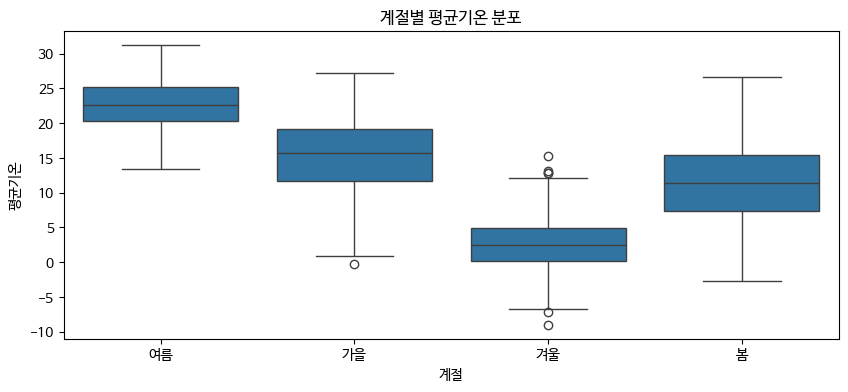

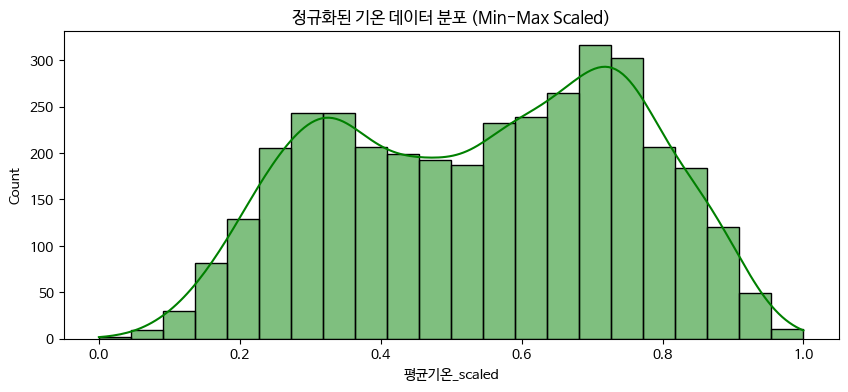

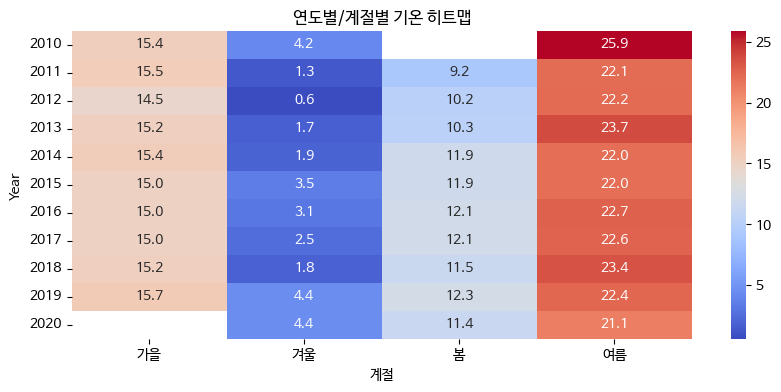

✅ weather_analysis_report.xlsx 저장 완료


In [16]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_environment():
  warnings.filterwarnings('ignore')

  font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
  if not os.path.exists(font_path):
      os.system('sudo apt-get install -y fonts-nanum > /dev/null')

  if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
  else:
    plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

  plt.rcParams['axes.unicode_minus'] = False
  print("✅ 환경 설정 및 한글 폰트 로드 완료")

def temp_change():
  data = pd.read_csv("https://github.com/dongupak/DataML/raw/main/csv/weather.csv", encoding="cp949")

  data['일시'] = pd.to_datetime(data['일시'])
  data = data.set_index('일시')

  data['이동평균'] = data['평균기온'].rolling(window=7).mean()

  plt.figure(figsize = (10, 4))
  plt.plot(data.index, data['평균기온'], color='lightgray', label='원본')
  plt.plot(data.index, data['이동평균'], color='red', label='7일 이동평균')
  plt.title('기온 시계열 변동 및 추세')
  plt.legend()
  plt.show()

def temp_season():
  data = pd.read_csv("https://github.com/dongupak/DataML/raw/main/csv/weather.csv", encoding="cp949")

  data['일시'] = pd.to_datetime(data['일시'])
  data = data.set_index('일시')

  data['월'] = data.index.month

  season_name = { 3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울' }
  data['계절'] = data['월'].map(season_name)

  plt.figure(figsize = (10, 4))
  sns.boxplot(data = data, x='계절', y='평균기온')
  plt.title('계절별 평균기온 분포')
  plt.show()

  season_temp_stats = data.groupby('계절')['평균기온'].agg(['mean', 'max', 'min', 'std']).round(2)
  return season_temp_stats

def min_max_scale(series):
  result = (series - series.min()) / (series.max() - series.min())
  return result

def temp_scaled():
  data = pd.read_csv("https://github.com/dongupak/DataML/raw/main/csv/weather.csv", encoding="cp949")

  data['일시'] = pd.to_datetime(data['일시'])
  data = data.set_index('일시')

  data['평균기온_scaled'] = min_max_scale(data['평균기온'])

  plt.figure(figsize = (10, 4))
  sns.histplot(data['평균기온_scaled'], color='green', kde=True)
  plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
  plt.show()

  return data['평균기온_scaled']

def temp_hitmap():
  data = pd.read_csv("https://github.com/dongupak/DataML/raw/main/csv/weather.csv", encoding="cp949")

  data['일시'] = pd.to_datetime(data['일시'])
  data = data.set_index('일시')

  data['Year'] = data.index.year
  data['월'] = data.index.month

  season_name = { 3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울' }
  data['계절'] = data['월'].map(season_name)

  remake_data = pd.pivot_table(data, index='Year', columns='계절', values='평균기온', aggfunc='mean')

  plt.figure(figsize=(10, 4))
  sns.heatmap(remake_data, annot=True, fmt='.1f', cmap='coolwarm')
  plt.title('연도별/계절별 기온 히트맵')
  plt.show()

  return remake_data

def export_to_excel(preprocessed, season_stats, year_pivot):
  with pd.ExcelWriter('weather_analysis_report.xlsx', engine='openpyxl') as writer:
    preprocessed.to_excel(writer, sheet_name='Preprocessed_Data', index=False)
    season_stats.to_excel(writer, sheet_name='Seasonal_Stats')
    year_pivot.to_excel(writer, sheet_name='Yearly_Pivot')
  print("✅ weather_analysis_report.xlsx 저장 완료")

def main():
  setup_environment()
  temp_change()
  season_stats = temp_season()
  preprocessed = temp_scaled()
  year_pivot = temp_hitmap()
  export_to_excel(preprocessed, season_stats, year_pivot)

if __name__ == '__main__':
  main()